In [ ]:
import sys
sys.path.append("..")

import json
from pathlib import Path
from core.chat2edit.models import Image
from core.chat2edit.functions.apply_filter import apply_filter
from core.chat2edit.functions.extract_object_by_sam import extract_object_by_sam
from core.chat2edit.functions.extract_objects_by_label import extract_objects_by_label
from core.chat2edit.functions.paste_entities import paste_entities
from core.chat2edit.functions.remove_entities import remove_entities
from core.chat2edit.functions.respond_to_user import respond_to_user
from core.chat2edit.functions.shift_entities import shift_entities
from core.chat2edit.models import Box, Object, Point

test_json_path = Path("../resources/images/test2.json")
with open(test_json_path, "r") as f:
    test_data = json.load(f)

image = Image.model_validate(test_data)
print(f"Loaded image: {image.width}x{image.height}")


c:\Users\nghia\miniconda3\envs\mic2e\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\nghia\miniconda3\envs\mic2e\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loaded image: 270.0x148.0


In [2]:
# Initialize predictor manager
from core.inference.manager import PredictorConfig, get_predictor_manager
from core.inference.predictors import (
    GroundingDinoObjectDetector,
    LamaImageInpainter,
    Sam2ObjectSegmenter,
    TwoStageObjectSegmenter,
)

predictor_manager = get_predictor_manager()

# Register Sam2ObjectSegmenter for SamBasedObjectSegmenter
sam2_segmenter = Sam2ObjectSegmenter(
    checkpoint_path="../resources/weights/sam2.1_hiera_large.pt",
    config_path="../config/sam2.1_hiera_1.yaml",
)

predictor_manager.register(
    PredictorConfig(
        predictor_class=Sam2ObjectSegmenter,
        init_args={},
        pool_size=1,
        device="cpu",
        preload=False,
        instance=sam2_segmenter,
    )
)

# Register GroundingDinoObjectDetector for TwoStageObjectSegmenter
label_based_object_detector = GroundingDinoObjectDetector(
    checkpoint_path="../resources/weights/groundingdino_swint_ogc.pth",
    config_path="../config/GroundingDINO_SwinT_OGC.py",
)

# Register TwoStageObjectSegmenter for LabelBasedObjectSegmenter
predictor_manager.register(
    PredictorConfig(
        predictor_class=TwoStageObjectSegmenter,
        init_args={
            "detector": label_based_object_detector,
            "segmenter": sam2_segmenter,
        },
        pool_size=1,
        device="cpu",
        preload=False,
    )
)

# Register LamaImageInpainter for MaskBasedImageInpainter
predictor_manager.register(
    PredictorConfig(
        predictor_class=LamaImageInpainter,
        init_args={"model_path": "../resources/weights/big-lama.pt"},
        pool_size=1,
        device="cuda",
        preload=False,
    )
)

await predictor_manager.initialize()
print("Predictor manager initialized successfully")


Predictor manager initialized successfully


In [3]:
# Test extract_objects_by_label
extracted_objects = await extract_objects_by_label(image, label="cat", num_expected_objects=1)
print(f"Extracted {len(extracted_objects)} objects with label 'cat'")


c:\Users\nghia\miniconda3\envs\mic2e\lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased


c:\Users\nghia\miniconda3\envs\mic2e\lib\site-packages\transformers\modeling_utils.py:1625: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
c:\Users\nghia\miniconda3\envs\mic2e\lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
c:\Users\nghia\miniconda3\envs\mic2e\lib\site-packages\torch\utils\checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
c:\Users\nghia\miniconda3\envs\mic2e\lib\site-packages\groundingdino\models\GroundingDINO\transformer.py:862: FutureWarning: `t

Extracted 1 objects with label 'cat'


''
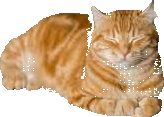

In [4]:
extracted_objects[0].src


In [5]:
# Test remove_entities
objects_to_remove = image.get_objects()[:2] if len(image.get_objects()) >= 2 else []
if objects_to_remove:
    result_image = await remove_entities(image, entities=objects_to_remove)
    print(f"Removed {len(objects_to_remove)} entities")
else:
    print("No objects to remove")


Removed 2 entities


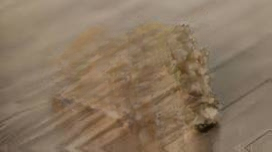

In [6]:
result_image.get_image()

In [14]:
from typing import List
from core.chat2edit.utils import create_composite_mask
from utils.image import expand_mask_image

def inpaint_objects(image: Image, objects: List[Object]) -> Image:
    """Inpaint objects in the image."""
    composite_mask = create_composite_mask(image, objects)
    expanded_mask = expand_mask_image(composite_mask, iterations=10)
    return expanded_mask

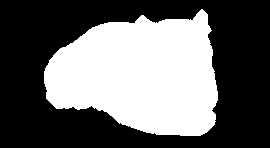

In [8]:
inpaint_objects(image, extracted_objects)

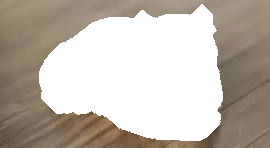

In [15]:
i = Image.model_validate(test_data).get_image()
i.paste(inpaint_objects(image, extracted_objects), (0, 0), inpaint_objects(image, extracted_objects))
i